<div align="center">

# TP3 - Projeto de Bloco: Análise e Segurança de Agentes de IA

</div>

##### Professor: Tiago Xavier;
###### Estudantes - E-mails:
###### Caio Ribeiro Pereira - caio.rpereira@al.infnet.edu.br;
###### Paulo Henrique de Paula Dias - paulo.dias@al.infnet.edu.br;
###### Pedro Marchiori de Araújo - pedro.maraujo@al.infnet.edu.br.

### Instruções

**Dataset**

O dataset utilizado é o *Customer Support Ticket Dataset*, disponível no Kaggle: https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data

#### Tarefa

Implemente um modelo de regressão linear no dataset (mesmo que a tarefa final seja de classificação — use uma variável numérica derivada, como frequência de palavras, comprimento do texto ou score de sentimento como variável alvo). Calcule R², RMSE e analise os resíduos com residual plot e Q-Q plot. Documente as limitações do modelo.

## 1. Definição do problema

O objetivo desta análise é prever o **número de palavras da descrição de um ticket** (`Numero de Palavras`), variável numérica derivada de `Ticket Description`. Essa variável representa uma aproximação simples do nível de detalhamento fornecido pelo cliente.

Foram escolhidos como preditores atributos disponíveis no ticket, incluindo a idade do cliente e variáveis categóricas de contexto (tipo, assunto, status, prioridade, canal, produto e gênero). Nenhuma característica calculada a partir da própria descrição é usada como entrada, evitando vazamento direto de informação.

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

cs_df = pd.read_csv("../data/customer_support_tickets.csv")
print(f"Dimensões do dataset: {cs_df.shape[0]} linhas e {cs_df.shape[1]} colunas")
cs_df.head()

Dimensões do dataset: 8469 linhas e 17 colunas


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 2. Preparação da variável alvo e dos preditores

In [57]:
dados_modelo = cs_df.copy()

# Alvo numérico derivado do texto principal
dados_modelo["Numero de Palavras"] = (
    dados_modelo["Ticket Description"]
    .fillna("")
    .str.findall(r"\b\w+\b")
    .str.len()
)

colunas_numericas = ["Customer Age"]
colunas_categoricas = [
    "Customer Gender",
    "Ticket Type",
    "Ticket Subject",
    "Ticket Status",
    "Ticket Priority",
    "Ticket Channel",
    "Product Purchased",
]
colunas_preditoras = colunas_numericas + colunas_categoricas

X = dados_modelo[colunas_preditoras]
y = dados_modelo["Numero de Palavras"]

dados_modelo[["Numero de Palavras"]].describe().round(2)

,Numero de Palavras
count,8469.00
mean,49.26
std,8.40
min,23.00
25%,46.00
50%,51.00
75%,55.00
max,65.00


## 3. Divisão treino/teste e pipeline de regressão linear

A separação é feita antes do ajuste do pré-processamento. A imputação e a codificação one-hot são aprendidas somente com o conjunto de treino por meio de um `Pipeline`, reduzindo o risco de vazamento entre treino e teste.

In [58]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

pipeline_categorico = Pipeline(steps=[
    ("imputacao", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessador = ColumnTransformer(transformers=[
    ("numericas", SimpleImputer(strategy="median"), colunas_numericas),
    ("categoricas", pipeline_categorico, colunas_categoricas),
])

modelo = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("regressao", LinearRegression()),
])

modelo.fit(X_treino, y_treino)
y_predito = modelo.predict(X_teste)

print(f"Observações de treino: {len(X_treino)}")
print(f"Observações de teste:  {len(X_teste)}")

Observações de treino: 6775
Observações de teste:  1694


## 4. Avaliação: R² e RMSE

O R² mede a proporção da variabilidade do alvo explicada pelo modelo no conjunto de teste; valores negativos indicam desempenho pior do que prever sempre a média do treino. O RMSE expressa o erro típico na mesma unidade do alvo, neste caso, palavras.

In [59]:
r2 = r2_score(y_teste, y_predito)
rmse = mean_squared_error(y_teste, y_predito) ** 0.5

print(f"R² (teste):   {r2:.4f}")
print(f"RMSE (teste): {rmse:.4f} palavras")

R² (teste):   -0.0055
RMSE (teste): 8.6128 palavras


## 5. Análise dos resíduos

Os resíduos são calculados como `valor observado - valor predito`. Em um modelo linear bem especificado, espera-se uma nuvem aproximadamente aleatória ao redor de zero, sem curvatura ou formato de funil. No gráfico Q-Q, pontos próximos da reta indicam maior compatibilidade dos resíduos com a distribuição normal.

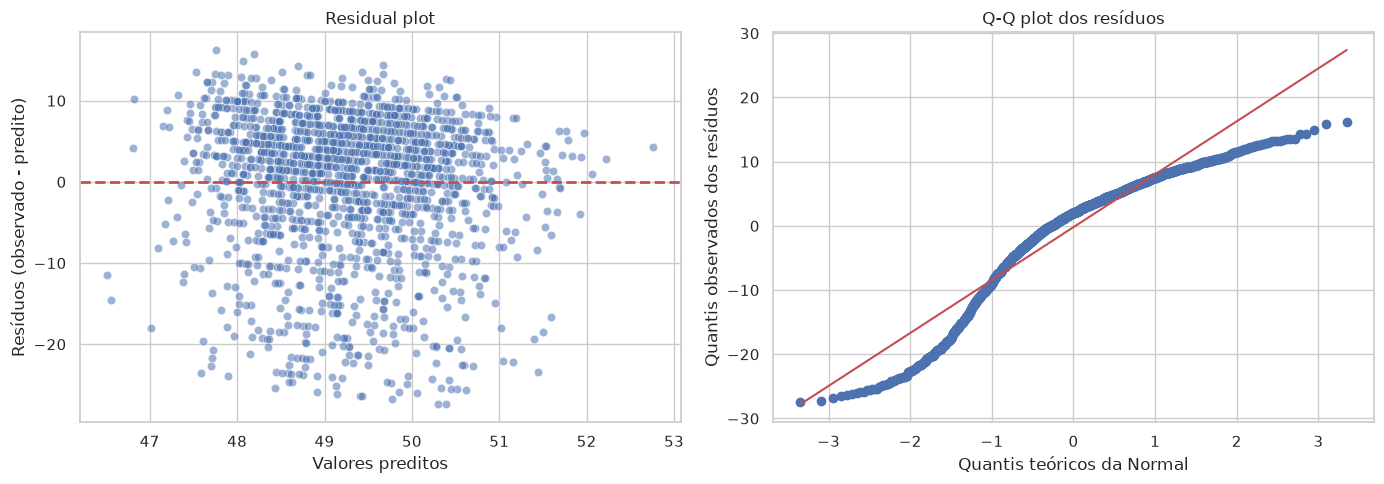

In [60]:
residuos = y_teste.to_numpy() - y_predito

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_predito, y=residuos, alpha=0.55, color="#4C72B0", ax=axes[0])
axes[0].axhline(0, color="#C44E52", linestyle="--", linewidth=2)
axes[0].set_title("Residual plot")
axes[0].set_xlabel("Valores preditos")
axes[0].set_ylabel("Resíduos (observado - predito)")

stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot dos resíduos")
axes[1].set_xlabel("Quantis teóricos da Normal")
axes[1].set_ylabel("Quantis observados dos resíduos")

plt.tight_layout()
plt.show()

In [61]:
resumo_residuos = pd.Series(residuos, name="Resíduos").describe()

print(resumo_residuos.round(3))
print(f"\nMédia dos resíduos: {residuos.mean():.4f}")
print(f"Faixa das predições: {y_predito.min():.1f} a {y_predito.max():.1f}")

count    1694.000
mean       -0.199
std         8.613
min       -27.392
25%        -4.126
50%         2.000
75%         5.821
max        16.238
Name: Resíduos, dtype: float64

Média dos resíduos: -0.1992
Faixa das predições: 46.5 a 52.8


### Interpretação dos resíduos

**Residual plot.** Os resíduos se distribuem em torno de zero, sem curvatura nem formato de funil evidentes, o que sugere variância aproximadamente constante. Um detalhe se destaca: as predições ficam confinadas a uma faixa estreita (cerca de 46,5 a 52,8 palavras), ou seja, o modelo prevê praticamente a média para todos os tickets.

**Q-Q plot.** Os pontos formam um **S** em torno da reta, com cauda esquerda mais longa (resíduos de até cerca de -27 contra cerca de +17 à direita). Isso indica **assimetria à esquerda** e é coerente com a mediana dos resíduos (+2,0) ser maior que a média (-0,20). A origem é o próprio alvo: como o modelo prevê quase a média, o resíduo é aproximadamente o alvo menos uma constante, e o alvo é assimétrico à esquerda (média 49,26 abaixo da mediana 51, mínimo 23; ver seção 2). A suposição de normalidade dos erros, portanto, não se sustenta.

**Leitura conjunta.** A média dos resíduos próxima de zero não indica bom ajuste neste caso: o modelo é praticamente uma constante e as médias de treino e teste são parecidas. O que mostra a falta de ajuste é o R² ≈ 0 e o RMSE de 8,61 palavras, próximo do desvio padrão do alvo (8,40 na base completa)

## 6. Limitações do modelo

- **Ausência de sinal nos preditores:** R² de teste ≈ 0 (ligeiramente negativo) e RMSE de 8,61 palavras. Idade e atributos categóricos do ticket não explicam linearmente o comprimento da descrição, e o modelo prevê praticamente a média para todos os tickets.
- **Alvo como aproximação:** o número de palavras mede extensão, não qualidade, urgência, complexidade.
- **Alvo discreto, não negativo e assimétrico à esquerda:** a regressão linear supõe resposta contínua e erros aproximadamente normais, e pode gerar predições negativas. 
- **Diagnóstico e generalização limitados:** as hipóteses do modelo foram avaliadas visualmente, com uma única divisão treino/teste; a codificação one-hot ignora categorias novas e não captura similaridade entre categorias; e os coeficientes indicam associação, não causalidade.

## 7. Conclusão

Foi implementada uma regressão linear para estimar o número de palavras da descrição de tickets de suporte, com pré-processamento dentro de um `Pipeline` e avaliação em amostra de teste separada. O modelo obteve $R^2 = -0,0055$ e RMSE de 8,61 palavras, ou seja, é equivalente a prever sempre a média: idade e atributos categóricos do ticket não explicam linearmente o tamanho da descrição neste dataset. Os resíduos têm média próxima de zero, mas o Q-Q plot em S mostra assimetria à esquerda herdada do alvo, e o residual plot evidencia predições comprimidas em uma faixa estreita. O resultado serve como linha de base negativa; alvos mais relacionados aos metadados (como score de sentimento) ou modelos para contagem poderiam ser avaliados em trabalhos futuros.